# Explanations of Value Tile & Co. (draft by Seb)

In [1]:
import matplotlib.pyplot as plt

from sorbetto.annotation import (
    AnnotationFrontiersBetweenRankings,
    AnnotationGeometric,
    AnnotationIsovalueCurves,
    AnnotationMax,
    AnnotationMin,
    AnnotationSymbols,
    AnnotationText,
)
from sorbetto.flavor import BestValueFlavor, EntityFlavor, ValueFlavor, WorstValueFlavor
from sorbetto.parameterization import ParameterizationDefault
from sorbetto.performance import (
    FiniteSetOfTwoClassClassificationPerformances,
    TwoClassClassificationPerformance,
)
from sorbetto.ranking import Entity, RankingScore
from sorbetto.tile import BestValueTile, EntityTile, ValueTile, WorstValueTile

In [2]:
def gen_standard_annotations(performance):
    yield AnnotationMin()
    yield AnnotationMax()
    yield AnnotationIsovalueCurves()
    yield AnnotationText(RankingScore.getTrueNegativeRate())
    yield AnnotationText(RankingScore.getTruePositiveRate())
    yield AnnotationText(RankingScore.getF(beta=0.5))
    yield AnnotationText(RankingScore.getF(beta=1.0))
    yield AnnotationText(RankingScore.getF(beta=2.0))
    yield AnnotationText(RankingScore.getInverseF(beta=0.5))
    yield AnnotationText(RankingScore.getInverseF(beta=1.0))
    yield AnnotationText(RankingScore.getInverseF(beta=2.0))
    yield AnnotationText(RankingScore.getAccuracy())
    yield AnnotationText(RankingScore.getNegativePredictiveValue())
    yield AnnotationText(RankingScore.getPositivePredictiveValue())
    yield AnnotationText(
        RankingScore.getMacroAveragedRecall(priorPos=performance._prior_pos())
    )
    yield AnnotationText(
        RankingScore.getMacroAveragedPrecision(ratePos=performance._rate_pos())
    )

In [3]:
def show_value_tile(ptn, pfp, pfn, ptp):
    performance = TwoClassClassificationPerformance(
        ptn, pfp, pfn, ptp, name="my performance"
    )
    flavor = ValueFlavor(performance, name="Value Flavor")
    parameterization = ParameterizationDefault()
    tile = ValueTile(parameterization, flavor)
    for annotation in gen_standard_annotations(performance):
        tile.appendAnnotation(annotation)
    try:
        annotation = AnnotationGeometric(tile.getPencil())
        tile.appendAnnotation(annotation)  # TODO: is this working ???
    except Exception:
        pass
    tile.draw()
    plt.show()
    print(tile.getExplanation())

In [4]:
def show_roc(ptn, pfp, pfn, ptp):
    performance = TwoClassClassificationPerformance(
        ptn, pfp, pfn, ptp, name="my performance"
    )

    performance.drawInROC(
        color_classifier="tab:blue",
        color_classifier_opp="tab:purple",
        color_classifier_neg="tab:orange",
        color_classifier_pos="tab:green",
    )
    plt.show()

In [5]:
def show_worst_tile(ptn, pfp, pfn, ptp):
    performance = TwoClassClassificationPerformance(
        ptn, pfp, pfn, ptp, name="my performance"
    )
    performance_opp = TwoClassClassificationPerformance(
        pfp, ptn, ptp, pfn, name="opposite performance"
    )
    performance_neg = TwoClassClassificationPerformance(
        ptn + pfp, 0.0, pfn + ptp, 0.0, name="predict neg"
    )
    performance_pos = TwoClassClassificationPerformance(
        0.0, ptn + pfp, 0.0, pfn + ptp, name="predict pos"
    )
    performances = [performance, performance_opp, performance_neg, performance_pos]
    performances = FiniteSetOfTwoClassClassificationPerformances(performances)
    flavor = WorstValueFlavor(performances=performances)

    parameterization = ParameterizationDefault()
    tile = WorstValueTile(parameterization, flavor)
    # TODO: AnnotationIsovalueCurves is not working. Why ??????????????????????????????
    for annotation in gen_standard_annotations(performance):
        tile.appendAnnotation(annotation)
    annotation = AnnotationFrontiersBetweenRankings(performances)
    tile.appendAnnotation(annotation)
    tile.draw()
    plt.show()
    print(tile.getExplanation())

In [6]:
def show_best_tile(ptn, pfp, pfn, ptp):
    performance = TwoClassClassificationPerformance(
        ptn, pfp, pfn, ptp, name="my performance"
    )
    performance_opp = TwoClassClassificationPerformance(
        pfp, ptn, ptp, pfn, name="opposite performance"
    )
    performance_neg = TwoClassClassificationPerformance(
        ptn + pfp, 0.0, pfn + ptp, 0.0, name="predict neg"
    )
    performance_pos = TwoClassClassificationPerformance(
        0.0, ptn + pfp, 0.0, pfn + ptp, name="predict pos"
    )
    performances = [performance, performance_opp, performance_neg, performance_pos]
    performances = FiniteSetOfTwoClassClassificationPerformances(performances)

    parameterization = ParameterizationDefault()

    flavor = BestValueFlavor(performances=performances)
    tile = BestValueTile(parameterization, flavor)
    annotation = AnnotationMin()
    tile.appendAnnotation(annotation)
    # TODO: AnnotationIsovalueCurves is not working. Why ??????????????????????????????
    for annotation in gen_standard_annotations(performance):
        tile.appendAnnotation(annotation)
    annotation = AnnotationFrontiersBetweenRankings(performances)
    tile.appendAnnotation(annotation)
    tile.draw()
    plt.show()
    print(tile.getExplanation())

    classifier = Entity(performance, "C", "tab:blue")
    classifier_opp = Entity(performance_opp, "¬C", "tab:purple")
    classifier_neg = Entity(performance_neg, "C-", "tab:orange")
    classifier_pos = Entity(performance_pos, "C+", "tab:green")
    entity_list = [classifier, classifier_opp, classifier_neg, classifier_pos]
    flavor = EntityFlavor(rank=1, entity_list=entity_list)
    tile = EntityTile(parameterization, flavor)
    annotation = AnnotationSymbols()
    tile.appendAnnotation(annotation)
    tile.draw()
    plt.show()
    print(tile.getExplanation())

In [7]:
def do_all(ptn, pfp, pfn, ptp):
    show_value_tile(ptn, pfp, pfn, ptp)
    show_roc(ptn, pfp, pfn, ptp)
    show_worst_tile(ptn, pfp, pfn, ptp)
    show_best_tile(ptn, pfp, pfn, ptp)

## Case in which $P({tn})=P({tp})$ and $P({fp})=P({fn})$

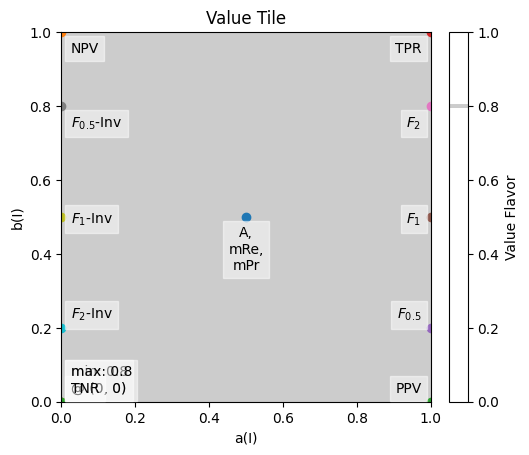

This Tile displays the flavor 'Value Flavor' for the performance 'my performance' (probabilities of a true negtive, false positive, false negative, and true positive of, respectively, 0.4, 0.1, 0.1, 0.4), with the parameterization 'default'.
This Tile is constant. This is because it is a very particular case in which the probabilities of a true negative and of a true positive are equal and the probabilities of a false positive and of a false negative are also equal. In other words, both class priors are equal to 0.5, the classifier is unbiased, and the opposite classifier is also unbiased. The value taken by all canonical ranking scores is 0.8.


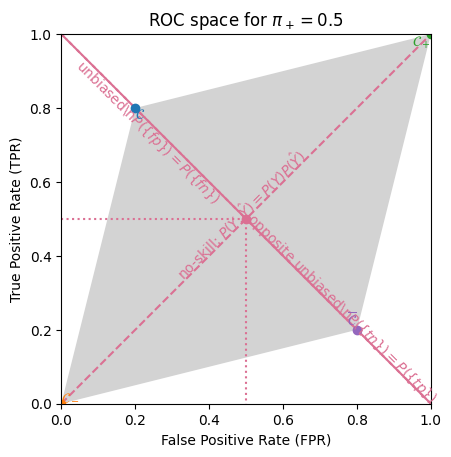

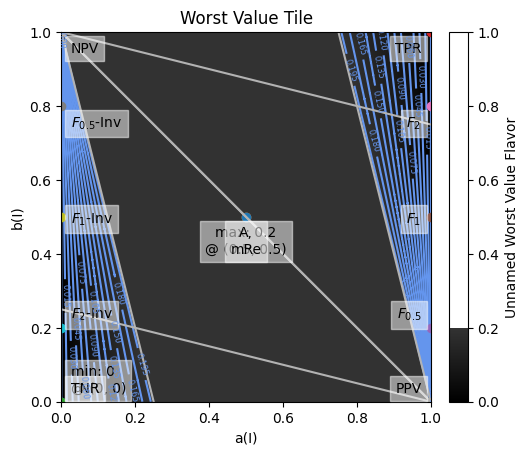

Explanation for this tile is not implemented yet


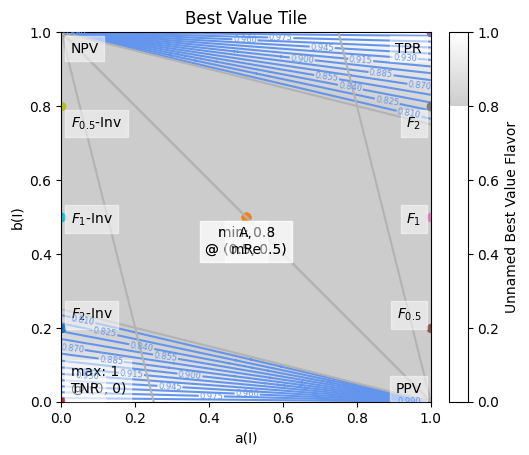

Explanation for this tile is not implemented yet


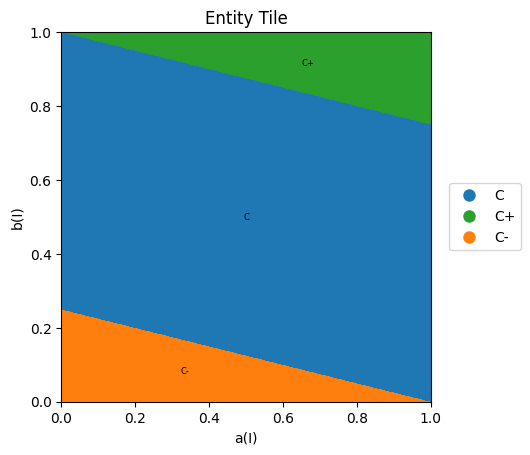

This Tile displays the flavor 'Unnamed Entity Flavor', with the parameterization 'default'.
 - [12.526 %] Entity `C-` with performance 
 TwoClassClassificationPerformance(name=predict neg, ptn=0.5, pfp=0.0, pfn=0.5, ptp=0.0)
 - [12.530 %] Entity `C+` with performance 
 TwoClassClassificationPerformance(name=predict pos, ptn=0.0, pfp=0.5, pfn=0.0, ptp=0.5)
 - [74.944 %] Entity `C` with performance 
 TwoClassClassificationPerformance(name=my performance, ptn=0.4, pfp=0.1, pfn=0.1, ptp=0.4)
Be aware that the coverage percentages given here-above are specific for the chosen parameterization.


In [8]:
do_all(0.4, 0.1, 0.1, 0.4)

## Case in which $P({tn})>P({tp})$ and $P({fp})=P({fn})$

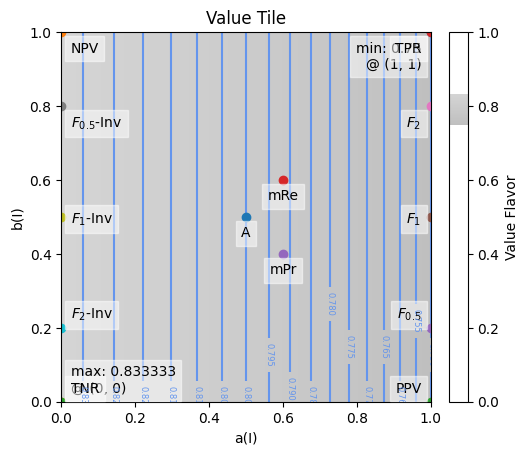

This Tile displays the flavor 'Value Flavor' for the performance 'my performance' (probabilities of a true negtive, false positive, false negative, and true positive of, respectively, 0.5, 0.1, 0.1, 0.3), with the parameterization 'default'. The value taken by canonical ranking scores is between 0.7499999999999999 and 0.8333333333333334. The mean value over the Tile, called 'Volume Under Tile' (VUT) with the default parameterization, is equal to 0.7972674459459179 (be careful as the score VUT cannot be used to rank).
This Tile does not show any vertical variation. This is because it is a very particular case in which the probabilities of a false positive and of a false negative are equal. The classifier is unbiased. However, the opposite classifier is biased.
As the probability of a true negative is higher than the probability of a true positive, the value taken by the canonical ranking scores is minimized at the right of the Tile, where no importance is given to the true negatives and

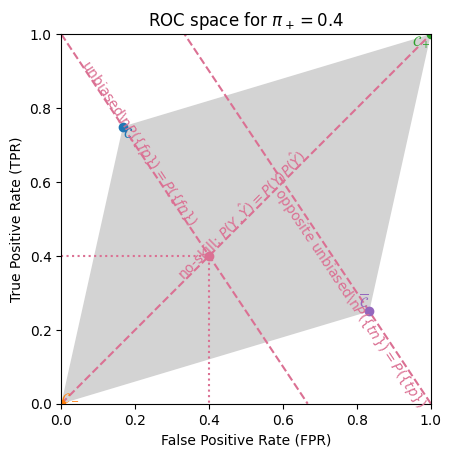

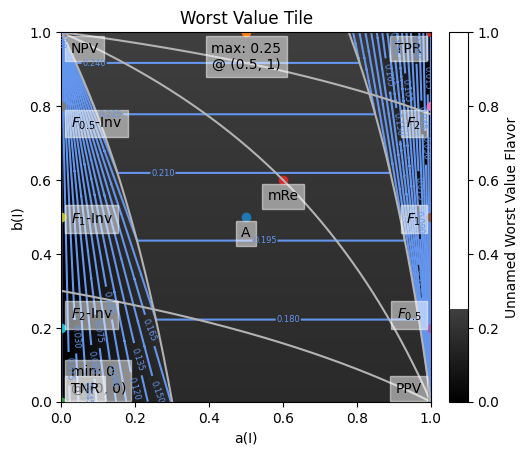

Explanation for this tile is not implemented yet


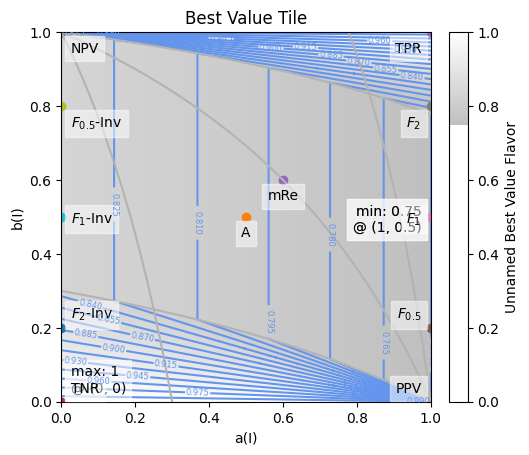

Explanation for this tile is not implemented yet


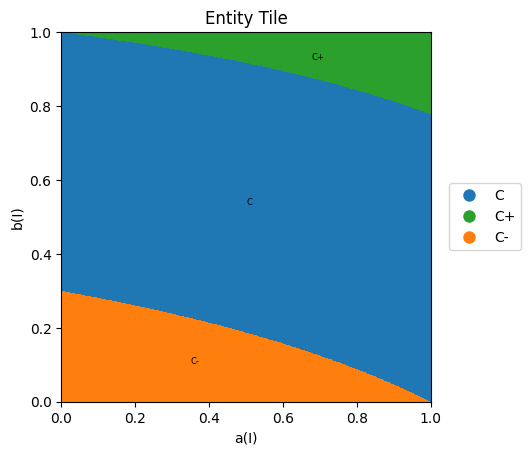

This Tile displays the flavor 'Unnamed Entity Flavor', with the parameterization 'default'.
 - [ 9.279 %] Entity `C+` with performance 
 TwoClassClassificationPerformance(name=predict pos, ptn=0.0, pfp=0.6, pfn=0.0, ptp=0.4)
 - [17.561 %] Entity `C-` with performance 
 TwoClassClassificationPerformance(name=predict neg, ptn=0.6, pfp=0.0, pfn=0.4, ptp=0.0)
 - [73.160 %] Entity `C` with performance 
 TwoClassClassificationPerformance(name=my performance, ptn=0.5, pfp=0.1, pfn=0.1, ptp=0.3)
Be aware that the coverage percentages given here-above are specific for the chosen parameterization.


In [9]:
do_all(0.5, 0.1, 0.1, 0.3)

## Case in which $P({tn})<P({tp})$ and $P({fp})=P({fn})$

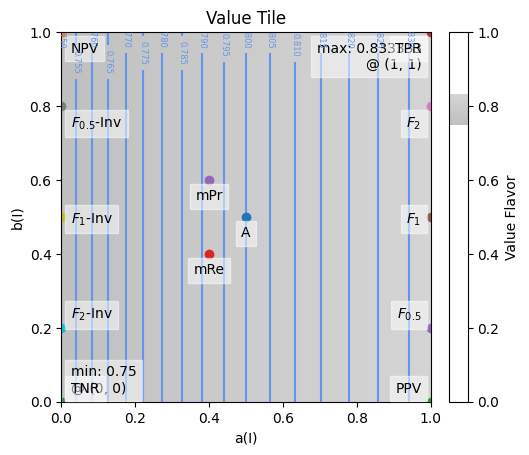

This Tile displays the flavor 'Value Flavor' for the performance 'my performance' (probabilities of a true negtive, false positive, false negative, and true positive of, respectively, 0.3, 0.1, 0.1, 0.5), with the parameterization 'default'. The value taken by canonical ranking scores is between 0.7499999999999999 and 0.8333333333333334. The mean value over the Tile, called 'Volume Under Tile' (VUT) with the default parameterization, is equal to 0.7972674459459179 (be careful as the score VUT cannot be used to rank).
This Tile does not show any vertical variation. This is because it is a very particular case in which the probabilities of a false positive and of a false negative are equal. The classifier is unbiased. However, the opposite classifier is biased.
As the probability of a true negative is lower than the probability of a true positive, the value taken by the canonical ranking scores is minimized at the left of the Tile, where no importance is given to the true positives and i

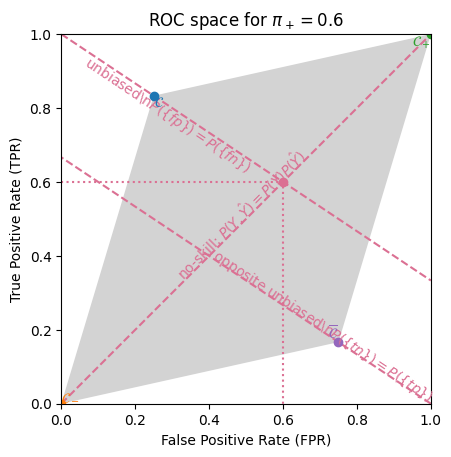

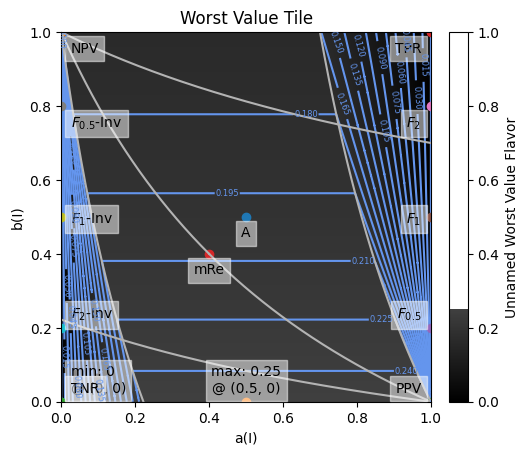

Explanation for this tile is not implemented yet


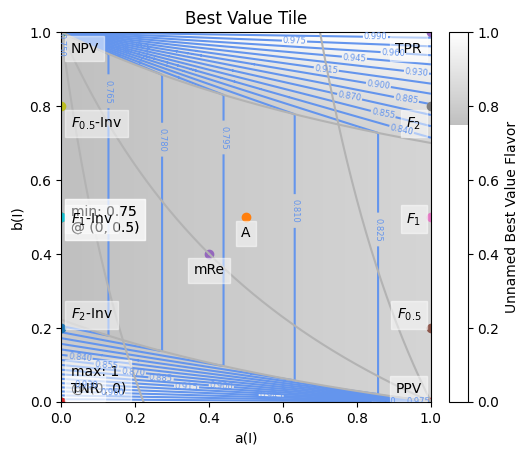

Explanation for this tile is not implemented yet


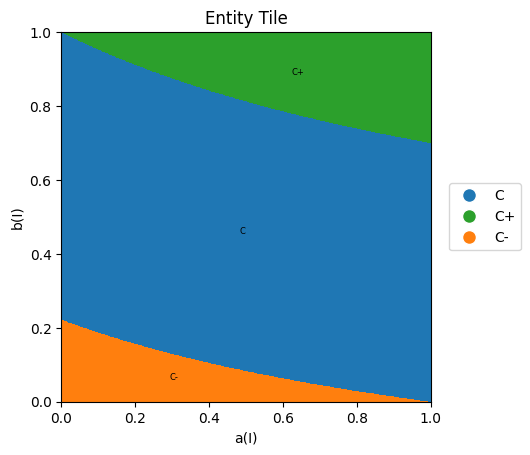

This Tile displays the flavor 'Unnamed Entity Flavor', with the parameterization 'default'.
 - [ 9.279 %] Entity `C-` with performance 
 TwoClassClassificationPerformance(name=predict neg, ptn=0.4, pfp=0.0, pfn=0.6, ptp=0.0)
 - [17.561 %] Entity `C+` with performance 
 TwoClassClassificationPerformance(name=predict pos, ptn=0.0, pfp=0.4, pfn=0.0, ptp=0.6)
 - [73.160 %] Entity `C` with performance 
 TwoClassClassificationPerformance(name=my performance, ptn=0.3, pfp=0.1, pfn=0.1, ptp=0.5)
Be aware that the coverage percentages given here-above are specific for the chosen parameterization.


In [10]:
do_all(0.3, 0.1, 0.1, 0.5)

## Case in which $P({tn})=P({tp})$ and $P({fp})>P({fn})$

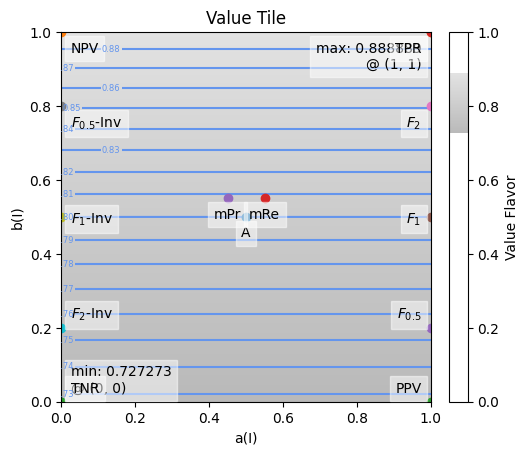

This Tile displays the flavor 'Value Flavor' for the performance 'my performance' (probabilities of a true negtive, false positive, false negative, and true positive of, respectively, 0.4, 0.15, 0.05, 0.4), with the parameterization 'default'. The value taken by canonical ranking scores is between 0.7272727272727273 and 0.888888888888889. The mean value over the Tile, called 'Volume Under Tile' (VUT) with the default parameterization, is equal to 0.8026827818486051 (be careful as the score VUT cannot be used to rank).
This Tile does not show any horizontal variation. This is because it is a very particular case in which the probabilities of a true negative and of a true positive are equal. The opposite classifier is unbiased. However, the classifier is biased.
As the probability of a false negative is lower than the probability of a false positive, the value taken by the canonical ranking scores is minimized at the bottom of the Tile, where no importance is given to the false negatives

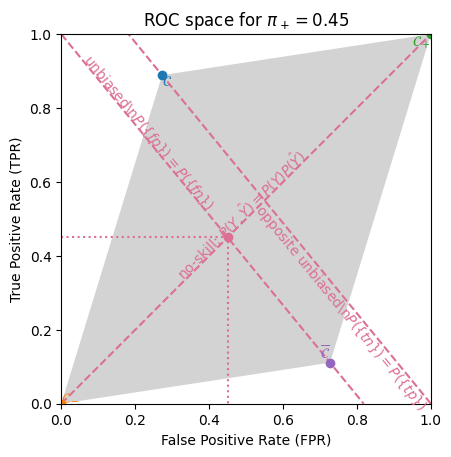

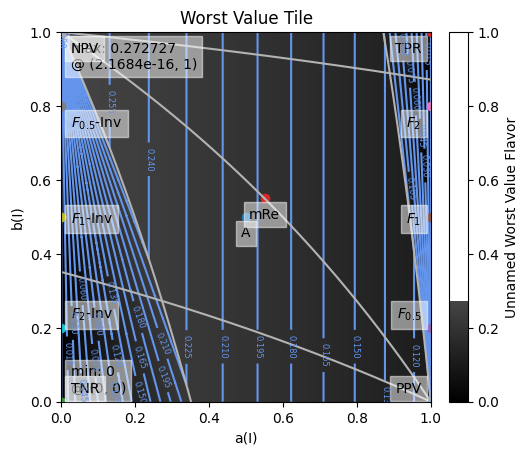

Explanation for this tile is not implemented yet


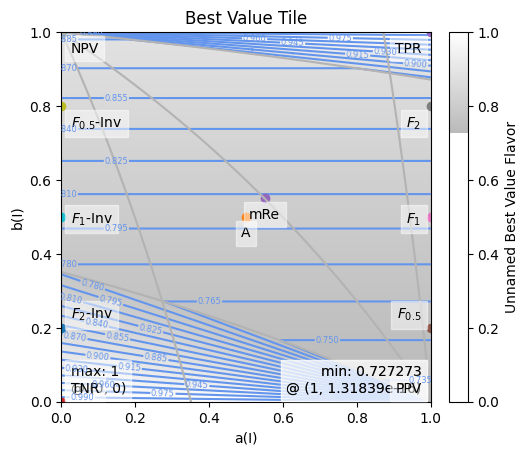

Explanation for this tile is not implemented yet


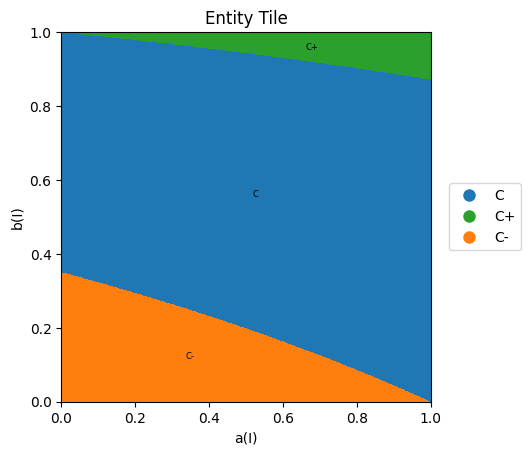

This Tile displays the flavor 'Unnamed Entity Flavor', with the parameterization 'default'.
 - [ 5.983 %] Entity `C+` with performance 
 TwoClassClassificationPerformance(name=predict pos, ptn=0.0, pfp=0.55, pfn=0.0, ptp=0.45)
 - [19.139 %] Entity `C-` with performance 
 TwoClassClassificationPerformance(name=predict neg, ptn=0.55, pfp=0.0, pfn=0.45, ptp=0.0)
 - [74.877 %] Entity `C` with performance 
 TwoClassClassificationPerformance(name=my performance, ptn=0.4, pfp=0.15, pfn=0.05, ptp=0.4)
Be aware that the coverage percentages given here-above are specific for the chosen parameterization.


In [11]:
do_all(0.4, 0.15, 0.05, 0.4)

## Case in which $P({tn})=P({tp})$ and $P({fp})<P({fn})$

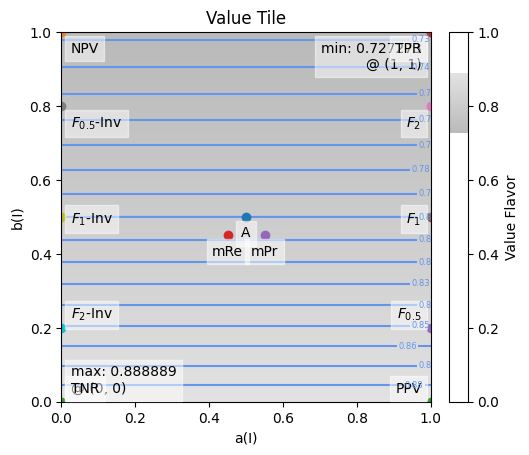

This Tile displays the flavor 'Value Flavor' for the performance 'my performance' (probabilities of a true negtive, false positive, false negative, and true positive of, respectively, 0.4, 0.05, 0.15, 0.4), with the parameterization 'default'. The value taken by canonical ranking scores is between 0.7272727272727273 and 0.888888888888889. The mean value over the Tile, called 'Volume Under Tile' (VUT) with the default parameterization, is equal to 0.8026827818486051 (be careful as the score VUT cannot be used to rank).
This Tile does not show any horizontal variation. This is because it is a very particular case in which the probabilities of a true negative and of a true positive are equal. The opposite classifier is unbiased. However, the classifier is biased.
As the probability of a false negative is higher than the probability of a false positive, the value taken by the canonical ranking scores is minimized at the top of the Tile, where no importance is given to the false positives a

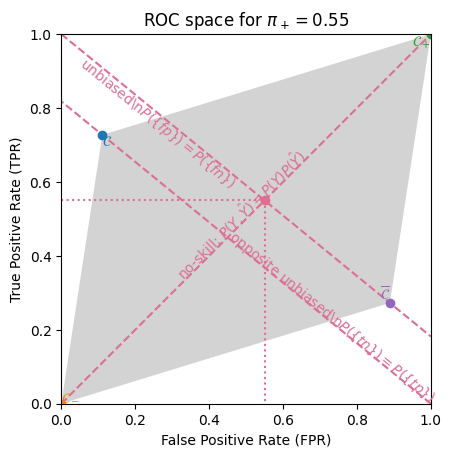

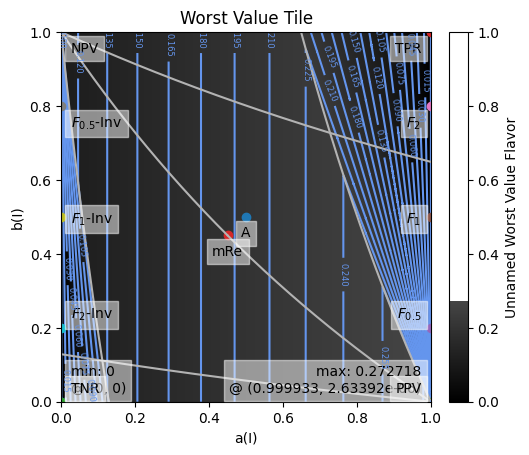

Explanation for this tile is not implemented yet


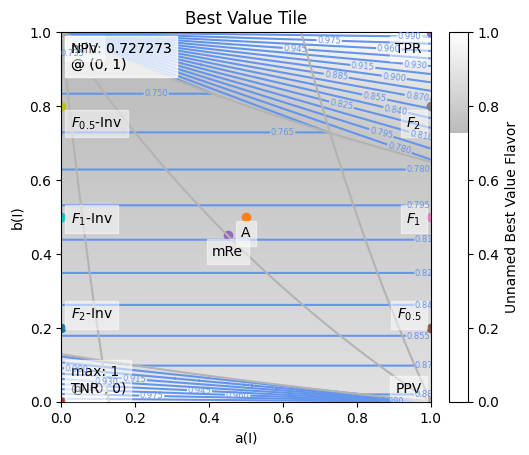

Explanation for this tile is not implemented yet


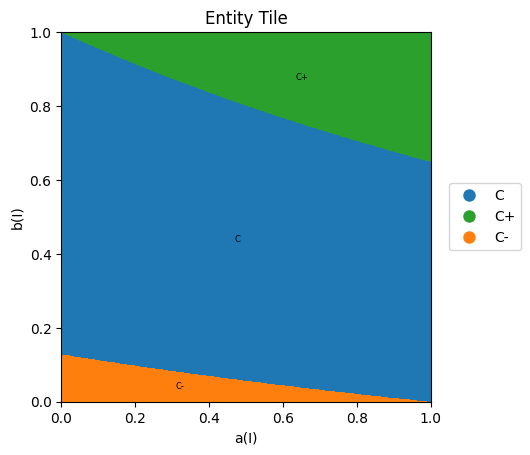

This Tile displays the flavor 'Unnamed Entity Flavor', with the parameterization 'default'.
 - [ 5.983 %] Entity `C-` with performance 
 TwoClassClassificationPerformance(name=predict neg, ptn=0.45, pfp=0.0, pfn=0.55, ptp=0.0)
 - [19.139 %] Entity `C+` with performance 
 TwoClassClassificationPerformance(name=predict pos, ptn=0.0, pfp=0.45, pfn=0.0, ptp=0.55)
 - [74.877 %] Entity `C` with performance 
 TwoClassClassificationPerformance(name=my performance, ptn=0.4, pfp=0.05, pfn=0.15, ptp=0.4)
Be aware that the coverage percentages given here-above are specific for the chosen parameterization.


In [12]:
do_all(0.4, 0.05, 0.15, 0.4)

## Case in which $P({tn})<P({tp})$ and $P({fp})<P({fn})$

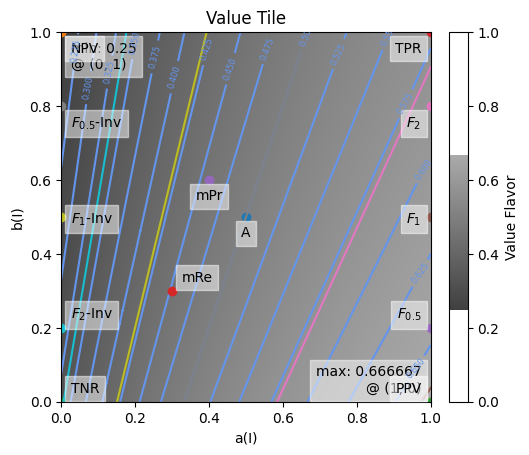

This Tile displays the flavor 'Value Flavor' for the performance 'my performance' (probabilities of a true negtive, false positive, false negative, and true positive of, respectively, 0.1, 0.2, 0.3, 0.4), with the parameterization 'default'. The value taken by canonical ranking scores is between 0.25 and 0.6666666666666666. The mean value over the Tile, called 'Volume Under Tile' (VUT) with the default parameterization, is equal to 0.45738771780266346 (be careful as the score VUT cannot be used to rank).
There are some horizontal and some vertical variations. This means that both the classifier and its opposite are biased. Values of canonical ranking scores increase towards the right of the Tile, which means that the probability of a true negative is lower that the probability of a true positive. Values of canonical ranking scores increase towards the bottom of the Tile, which means that the probability of a false positive is lower that the probability of a false negative.
With the par

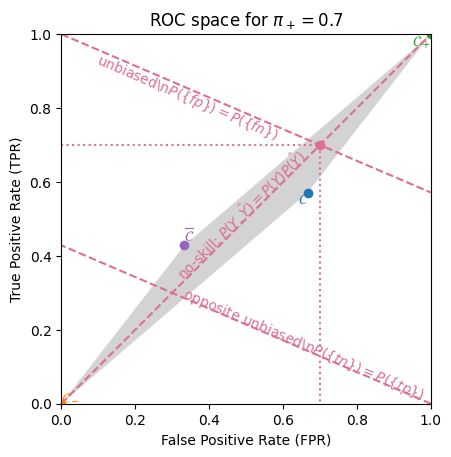

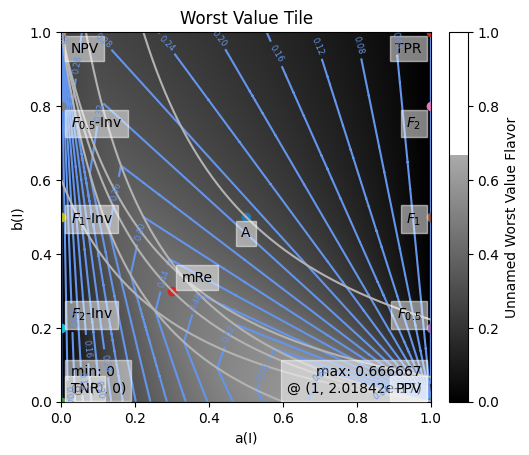

Explanation for this tile is not implemented yet


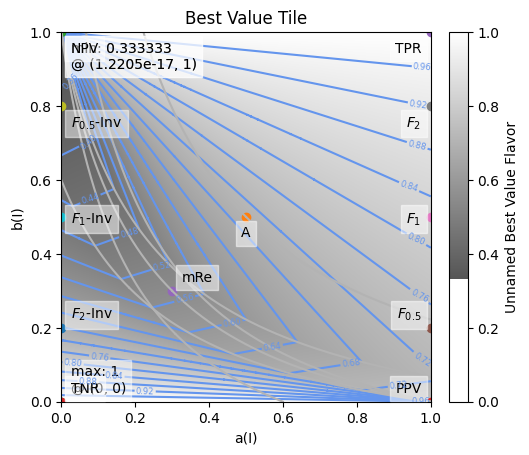

Explanation for this tile is not implemented yet


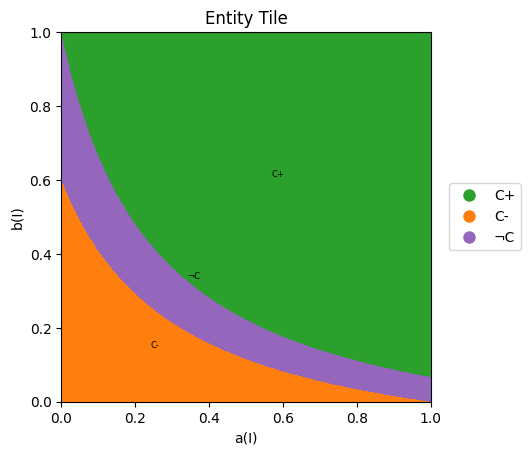

This Tile displays the flavor 'Unnamed Entity Flavor', with the parameterization 'default'.
 - [13.705 %] Entity `¬C` with performance 
 TwoClassClassificationPerformance(name=opposite performance, ptn=0.2, pfp=0.1, pfn=0.4, ptp=0.3)
 - [16.612 %] Entity `C-` with performance 
 TwoClassClassificationPerformance(name=predict neg, ptn=0.30000000000000004, pfp=0.0, pfn=0.7, ptp=0.0)
 - [69.682 %] Entity `C+` with performance 
 TwoClassClassificationPerformance(name=predict pos, ptn=0.0, pfp=0.30000000000000004, pfn=0.0, ptp=0.7)
Be aware that the coverage percentages given here-above are specific for the chosen parameterization.


In [13]:
do_all(0.1, 0.2, 0.3, 0.4)

## Case in which $P({tn})>P({tp})$ and $P({fp})<P({fn})$

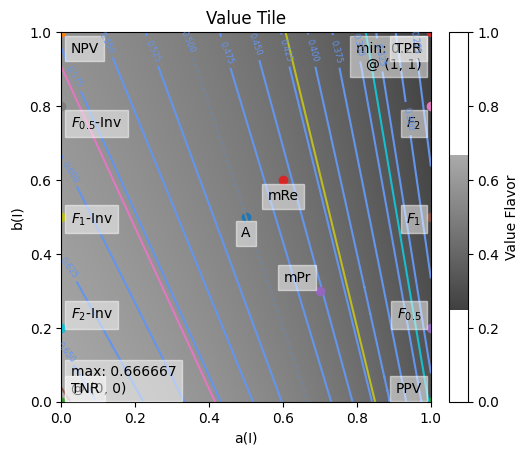

This Tile displays the flavor 'Value Flavor' for the performance 'my performance' (probabilities of a true negtive, false positive, false negative, and true positive of, respectively, 0.4, 0.2, 0.3, 0.1), with the parameterization 'default'. The value taken by canonical ranking scores is between 0.25 and 0.6666666666666666. The mean value over the Tile, called 'Volume Under Tile' (VUT) with the default parameterization, is equal to 0.4786938589013317 (be careful as the score VUT cannot be used to rank).
There are some horizontal and some vertical variations. This means that both the classifier and its opposite are biased. Values of canonical ranking scores increase towards the left of the Tile, which means that the probability of a true negative is higher that the probability of a true positive. Values of canonical ranking scores increase towards the bottom of the Tile, which means that the probability of a false positive is lower that the probability of a false negative.
With the para

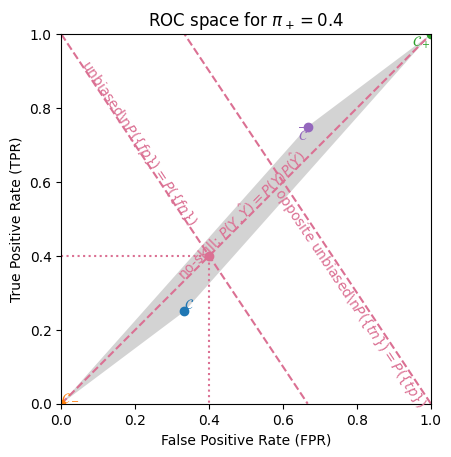

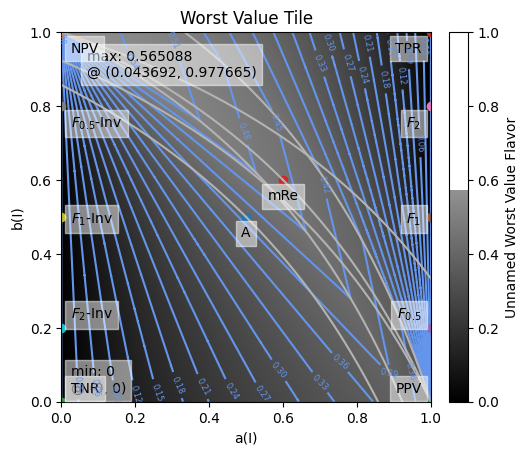

Explanation for this tile is not implemented yet


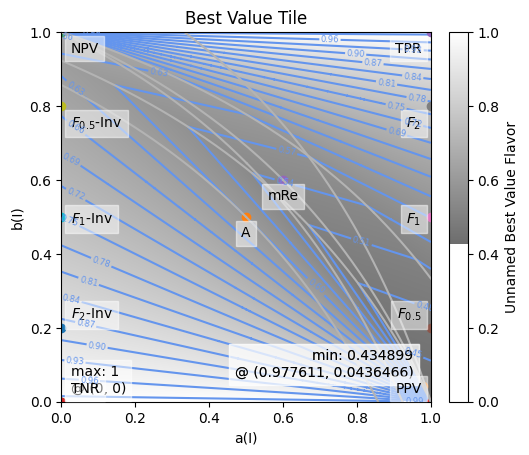

Explanation for this tile is not implemented yet


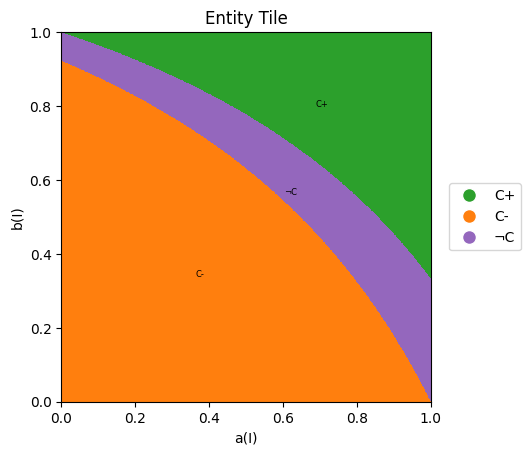

This Tile displays the flavor 'Unnamed Entity Flavor', with the parameterization 'default'.
 - [16.419 %] Entity `¬C` with performance 
 TwoClassClassificationPerformance(name=opposite performance, ptn=0.2, pfp=0.4, pfn=0.1, ptp=0.3)
 - [25.784 %] Entity `C+` with performance 
 TwoClassClassificationPerformance(name=predict pos, ptn=0.0, pfp=0.6000000000000001, pfn=0.0, ptp=0.4)
 - [57.797 %] Entity `C-` with performance 
 TwoClassClassificationPerformance(name=predict neg, ptn=0.6000000000000001, pfp=0.0, pfn=0.4, ptp=0.0)
Be aware that the coverage percentages given here-above are specific for the chosen parameterization.


In [14]:
do_all(0.4, 0.2, 0.3, 0.1)

## Case in which $P({tn})<P({tp})$ and $P({fp})>P({fn})$

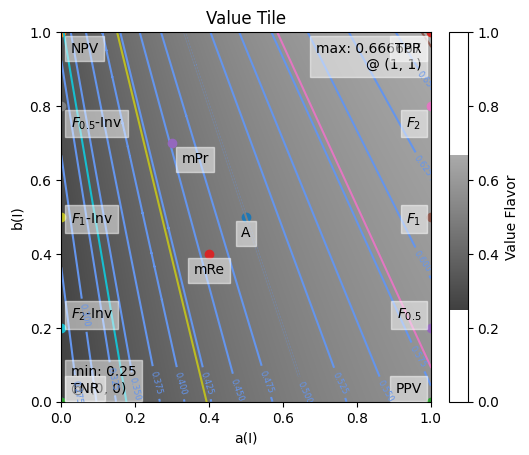

This Tile displays the flavor 'Value Flavor' for the performance 'my performance' (probabilities of a true negtive, false positive, false negative, and true positive of, respectively, 0.1, 0.3, 0.2, 0.4), with the parameterization 'default'. The value taken by canonical ranking scores is between 0.25 and 0.6666666666666666. The mean value over the Tile, called 'Volume Under Tile' (VUT) with the default parameterization, is equal to 0.4786938589013321 (be careful as the score VUT cannot be used to rank).
There are some horizontal and some vertical variations. This means that both the classifier and its opposite are biased. Values of canonical ranking scores increase towards the right of the Tile, which means that the probability of a true negative is lower that the probability of a true positive. Values of canonical ranking scores increase towards the top of the Tile, which means that the probability of a false positive is higher that the probability of a false negative.
With the parame

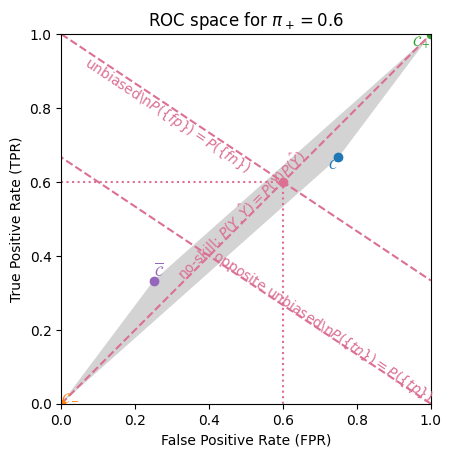

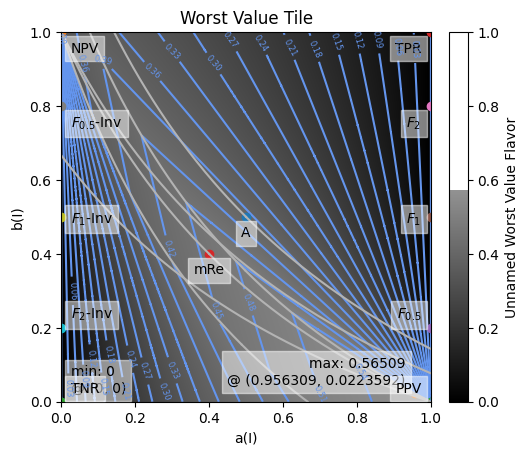

Explanation for this tile is not implemented yet


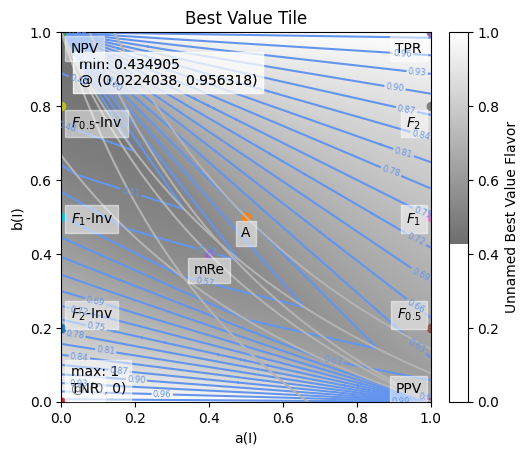

Explanation for this tile is not implemented yet


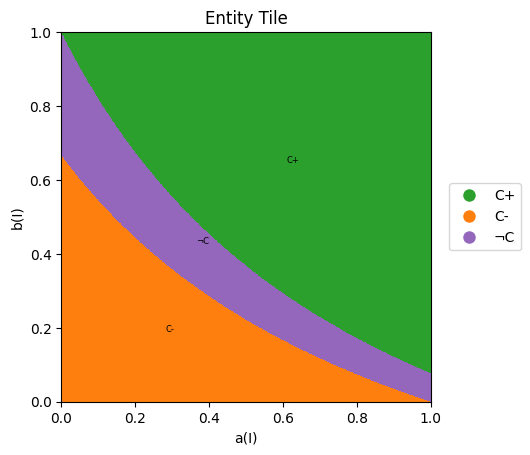

This Tile displays the flavor 'Unnamed Entity Flavor', with the parameterization 'default'.
 - [16.419 %] Entity `¬C` with performance 
 TwoClassClassificationPerformance(name=opposite performance, ptn=0.3, pfp=0.1, pfn=0.4, ptp=0.2)
 - [25.784 %] Entity `C-` with performance 
 TwoClassClassificationPerformance(name=predict neg, ptn=0.4, pfp=0.0, pfn=0.6000000000000001, ptp=0.0)
 - [57.797 %] Entity `C+` with performance 
 TwoClassClassificationPerformance(name=predict pos, ptn=0.0, pfp=0.4, pfn=0.0, ptp=0.6000000000000001)
Be aware that the coverage percentages given here-above are specific for the chosen parameterization.


In [15]:
do_all(0.1, 0.3, 0.2, 0.4)

## Case in which $P({tn})>P({tp})$ and $P({fp})>P({fn})$

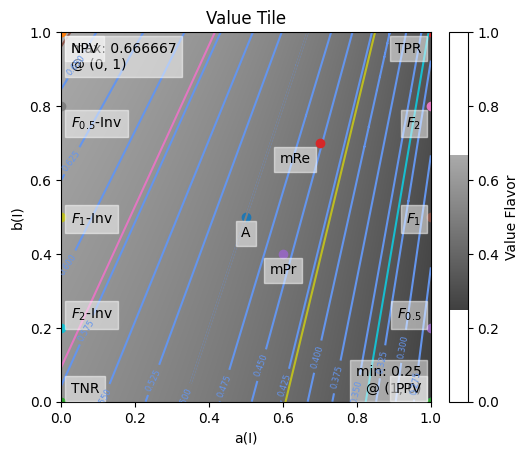

This Tile displays the flavor 'Value Flavor' for the performance 'my performance' (probabilities of a true negtive, false positive, false negative, and true positive of, respectively, 0.4, 0.3, 0.2, 0.1), with the parameterization 'default'. The value taken by canonical ranking scores is between 0.25 and 0.6666666666666666. The mean value over the Tile, called 'Volume Under Tile' (VUT) with the default parameterization, is equal to 0.4573877178026638 (be careful as the score VUT cannot be used to rank).
There are some horizontal and some vertical variations. This means that both the classifier and its opposite are biased. Values of canonical ranking scores increase towards the left of the Tile, which means that the probability of a true negative is higher that the probability of a true positive. Values of canonical ranking scores increase towards the top of the Tile, which means that the probability of a false positive is higher that the probability of a false negative.
With the parame

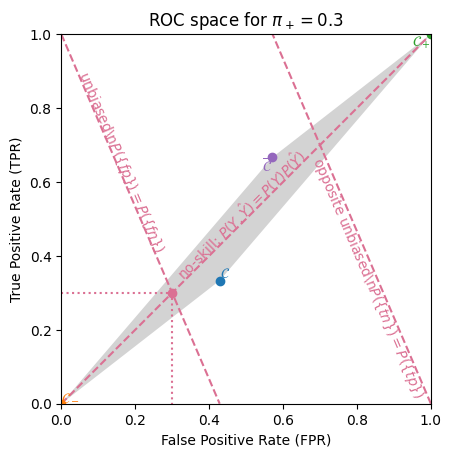

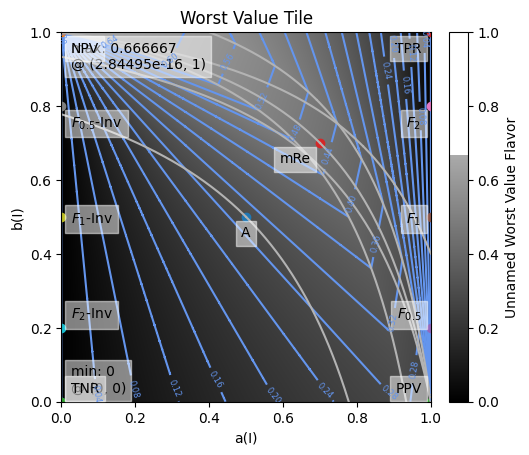

Explanation for this tile is not implemented yet


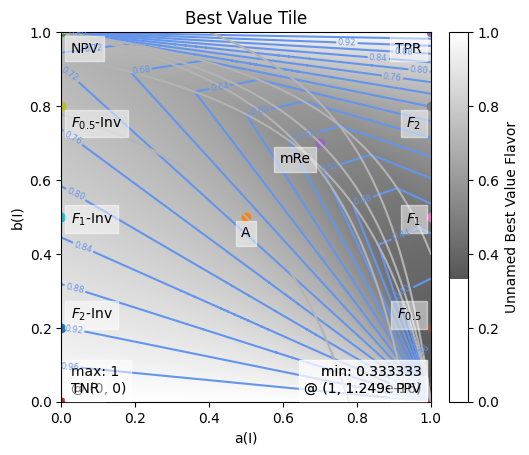

Explanation for this tile is not implemented yet


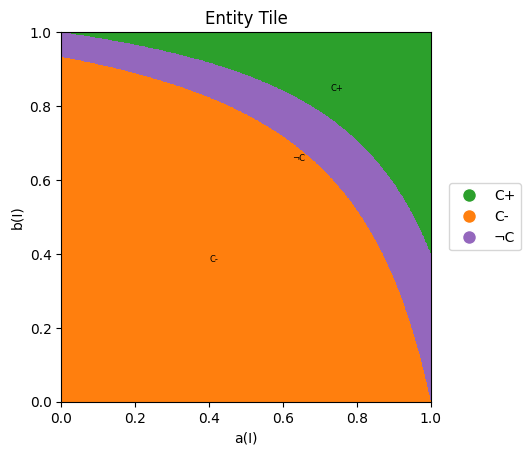

This Tile displays the flavor 'Unnamed Entity Flavor', with the parameterization 'default'.
 - [13.705 %] Entity `¬C` with performance 
 TwoClassClassificationPerformance(name=opposite performance, ptn=0.3, pfp=0.4, pfn=0.1, ptp=0.2)
 - [16.613 %] Entity `C+` with performance 
 TwoClassClassificationPerformance(name=predict pos, ptn=0.0, pfp=0.7, pfn=0.0, ptp=0.30000000000000004)
 - [69.682 %] Entity `C-` with performance 
 TwoClassClassificationPerformance(name=predict neg, ptn=0.7, pfp=0.0, pfn=0.30000000000000004, ptp=0.0)
Be aware that the coverage percentages given here-above are specific for the chosen parameterization.


In [16]:
do_all(0.4, 0.3, 0.2, 0.1)

## EXPERIMENTAL !!!!!!!!!!!!!!!!!

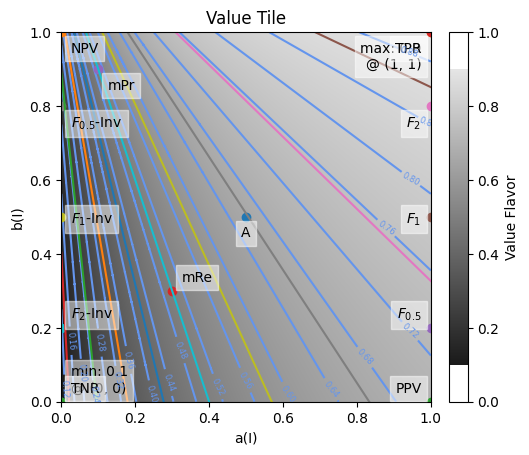

This Tile displays the flavor 'Value Flavor' for the performance 'my performance' (probabilities of a true negtive, false positive, false negative, and true positive of, respectively, 0.03, 0.2700000000000001, 0.06999999999999998, 0.63), with the parameterization 'default'. The value taken by canonical ranking scores is between 0.09999999999999998 and 0.9. The mean value over the Tile, called 'Volume Under Tile' (VUT) with the default parameterization, is equal to 0.6259110241578402 (be careful as the score VUT cannot be used to rank).
There are some horizontal and some vertical variations. This means that both the classifier and its opposite are biased. Values of canonical ranking scores increase towards the right of the Tile, which means that the probability of a true negative is lower that the probability of a true positive. Values of canonical ranking scores increase towards the top of the Tile, which means that the probability of a false positive is higher that the probability of 

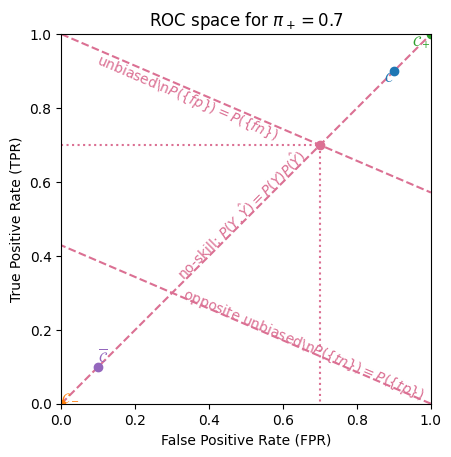

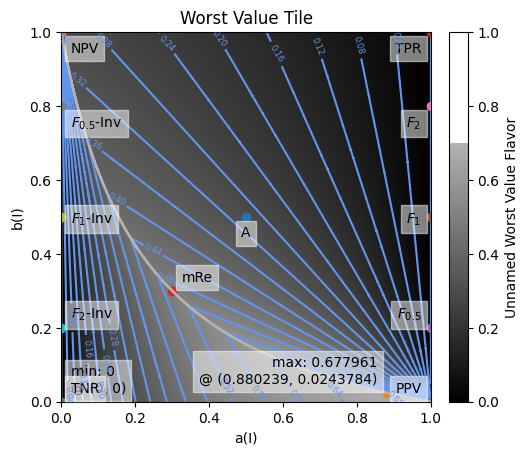

Explanation for this tile is not implemented yet


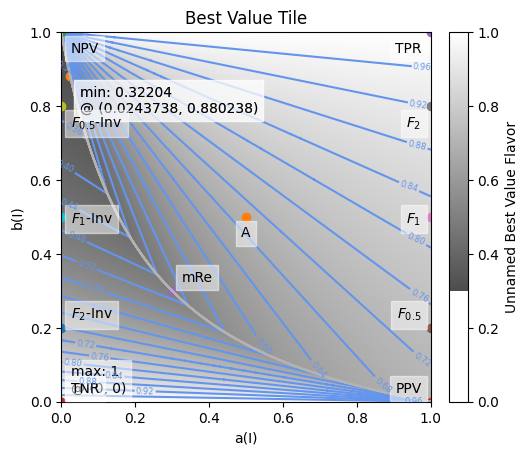

Explanation for this tile is not implemented yet


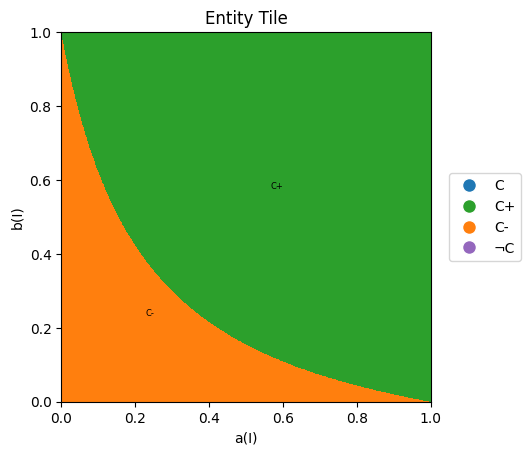

This Tile displays the flavor 'Unnamed Entity Flavor', with the parameterization 'default'.
 - [ 0.000 %] Entity `C` with performance 
 TwoClassClassificationPerformance(name=my performance, ptn=0.03, pfp=0.2700000000000001, pfn=0.06999999999999998, ptp=0.63)
 - [ 0.000 %] Entity `¬C` with performance 
 TwoClassClassificationPerformance(name=opposite performance, ptn=0.2700000000000001, pfp=0.03, pfn=0.63, ptp=0.06999999999999998)
 - [24.259 %] Entity `C-` with performance 
 TwoClassClassificationPerformance(name=predict neg, ptn=0.30000000000000004, pfp=0.0, pfn=0.7, ptp=0.0)
 - [75.740 %] Entity `C+` with performance 
 TwoClassClassificationPerformance(name=predict pos, ptn=0.0, pfp=0.30000000000000004, pfn=0.0, ptp=0.7)
Be aware that the coverage percentages given here-above are specific for the chosen parameterization.


In [17]:
p = TwoClassClassificationPerformance.getNoSkill(ratePos=0.9, priorPos=0.7)
do_all(p.ptn, p.pfp, p.pfn, p.ptp)